# **Implementation of Tiny VGG Convolutional Neural Network using PyTorch**

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.8 MB/s eta 0:00:00


In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib and pandas for visualization
import matplotlib.pyplot as plt
import pandas as pd

# Import accuracy function for measure accuracy
from torchmetrics.classification import MulticlassAccuracy

# Import timeit to measure time
from timeit import default_timer as timer

# Import tqdm for progress bar
from tqdm.auto import tqdm

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", #data downloading path
    train = True, #get training data
    download = True,  #download data
    transform = ToTensor(), #convert images from PIL to Torch tensors
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False, #get test data
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.6MB/s]


In [ ]:
#Size of an image and label
image,label=test_data[0]
image.shape,label

(torch.Size([1, 28, 28]), 9)

In [ ]:
# Classes of the dataset
class_names=test_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# Size of the samples
len(train_data.data),len(train_data.targets),len(test_data.data),len(test_data.targets)

(60000, 60000, 10000, 10000)

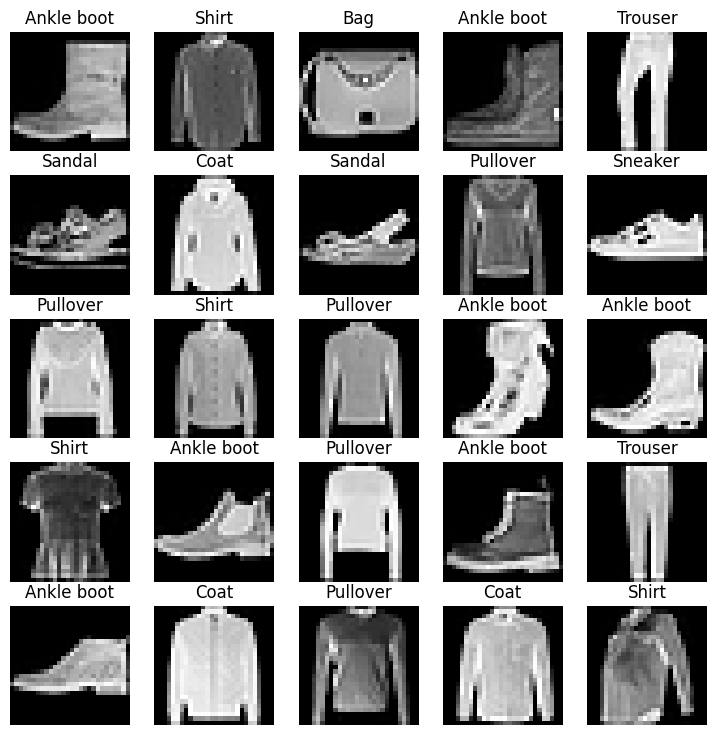

In [ ]:
#Plot couple of images from the data
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=5,5
for i in range (1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [ ]:
# Create mini-batches of training data using PyTorch DataLoader
from torch.utils.data import DataLoader

# Setup the batch size
BATCH_SIZE=32

#Turn datasets into iterable (batches)
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True
                              )

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [ ]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
# Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
#Create a Convolutional Neural Network
class TinyVGGRep(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,Output_shape:int):
    super().__init__()
    self.block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    self.block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    self.classifier=nn.Sequential(
      nn.Flatten(),
      nn.LazyLinear(out_features=Output_shape)


    )

  def forward(self,x:torch.Tensor):
    return self.classifier(self.block_2(self.block_1(x)))

In [ ]:
torch.manual_seed(42)
model=TinyVGGRep(input_shape=1,
                 hidden_units=10,
                 Output_shape=len(class_names)).to(device)
model


TinyVGGRep(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=10, bias=True)
  )
)

In [ ]:
# Setup optimizer and loss function
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(), lr=0.1)

In [ ]:
#Setup accuracy function
accuracy_fn=MulticlassAccuracy(num_classes=len(class_names)).to(device)

In [ ]:
# Create functions for training and testing steps
def train_step(data_loader:torch.utils.data.DataLoader,
               model:torch.nn.Module,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn:torch.nn.Module,
               device:torch.device=device):
  train_loss,train_acc=0,0
  for batch,(X,y) in enumerate(data_loader):
    #send data to GPU
    X,y = X.to(device), y.to(device)

    # 1.Forward pass
    y_pred=model(X)

    # 2.Calculate loss
    loss=loss_fn(y_pred,y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_pred.argmax(dim=1),y)

    # 3.Optimizer zero grad
    optimizer.zero_grad()

    # 4.Back propagation
    loss.backward()

    # 5. Update parameters
    optimizer.step()

  #Calculate loss and accuracy per epoch and print out what's happening
  train_loss /= len(data_loader)
  train_accuracy =train_acc/len(data_loader)*100

  print(f"Train Loss: {train_loss:.5f}  | Train Accuracy: {train_accuracy:.2f}%")

def test_step(data_loader:torch.utils.data.DataLoader,
               model:torch.nn.Module,
               loss_fn:torch.nn.Module,
               accuracy_fn=torch.nn.Module,
               device:torch.device=device
               ):
  test_loss,test_acc=0,0
  model.eval() #Put model in eval mode

  #Turn on inference context manager
  with torch.inference_mode():
    for X,y in data_loader:

      #Send data to GPU
      X,y=X.to(device),y.to(device)

      # 1.Forward pass
      test_pred=model(X)

      # 2.Calculate loss and accuracy
      test_loss+=loss_fn(test_pred,y).item()
      test_acc +=accuracy_fn(test_pred.argmax(dim=1),y)

    # Calculate final test loss and accuracy and Print out the results
    test_loss /= len(data_loader)
    test_acc =test_acc/len(data_loader)*100
    print(f"Test Loss: {test_loss:.5f}  | Test Accuracy: {test_acc:.2f}%")

In [ ]:
#Set the seed and start the timer
torch.manual_seed(42)
train_start=timer()

epochs=5
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n----------------------------------------")
  train_step(data_loader=train_dataloader,
             model=model,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

  test_step(data_loader=test_dataloader,
            model=model,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)

  train_end=timer()

  total_time=train_end-train_start
  print(f"Train time: {total_time:.2f} seconds\n")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
----------------------------------------
Train Loss: 0.23586  | Train Accuracy: 90.61%
Test Loss: 0.28201  | Test Accuracy: 89.24%
Train time: 15.14 seconds

Epoch: 1
----------------------------------------
Train Loss: 0.23389  | Train Accuracy: 90.82%
Test Loss: 0.30163  | Test Accuracy: 88.59%
Train time: 30.80 seconds

Epoch: 2
----------------------------------------
Train Loss: 0.23286  | Train Accuracy: 90.58%
Test Loss: 0.29506  | Test Accuracy: 88.80%
Train time: 45.19 seconds

Epoch: 3
----------------------------------------
Train Loss: 0.22792  | Train Accuracy: 91.04%
Test Loss: 0.27317  | Test Accuracy: 89.54%
Train time: 59.46 seconds

Epoch: 4
----------------------------------------
Train Loss: 0.22550  | Train Accuracy: 91.18%
Test Loss: 0.29991  | Test Accuracy: 89.06%
Train time: 73.94 seconds



In [ ]:
# Get trained model results
torch.manual_seed(42)

loss,acc=0,0

model.eval()
with torch.inference_mode():
  for X,y in test_dataloader:
    # Copy data into the target device
    X,y=X.to(device),y.to(device)
    #Make prediction with the trained model
    y_pred=model(X)

    #Accumulate the loss and accuracy values per batch
    loss+=loss_fn(y_pred,y)
    acc+=accuracy_fn(y_pred.argmax(dim=1),y)

  # Average loss and accuracy per batch
  loss/=len(test_dataloader)
  acc=acc/len(test_dataloader)*100

print(f"Loss: {loss:.5f}  | Accuracy: {acc:.2f}%")

Loss: 0.29995  | Accuracy: 89.15%


In [74]:
# Check Predictions
import random

random.seed(42)
test_sample=[]
test_label=[]
for sample,label in random.sample(list(test_data),k=25):
  test_sample.append(sample)
  test_label.append(label)

preds_ls=[]

model.eval()
with torch.inference_mode():
  for sample in test_sample:
    sample=torch.unsqueeze(sample,dim=0).to(device)
    #Forward pass
    pred_logit=model(sample)
    pred=torch.softmax(pred_logit.squeeze(),dim=0)

    #Get prediction
    preds_ls.append(pred.cpu())

  preds=torch.stack(preds_ls)

In [ ]:
pred_classes=preds.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 6, 4, 7, 1, 9, 7, 2, 0, 1, 0, 3, 5, 4, 2, 4, 4, 3, 2, 2,
        0], device='cuda:0')

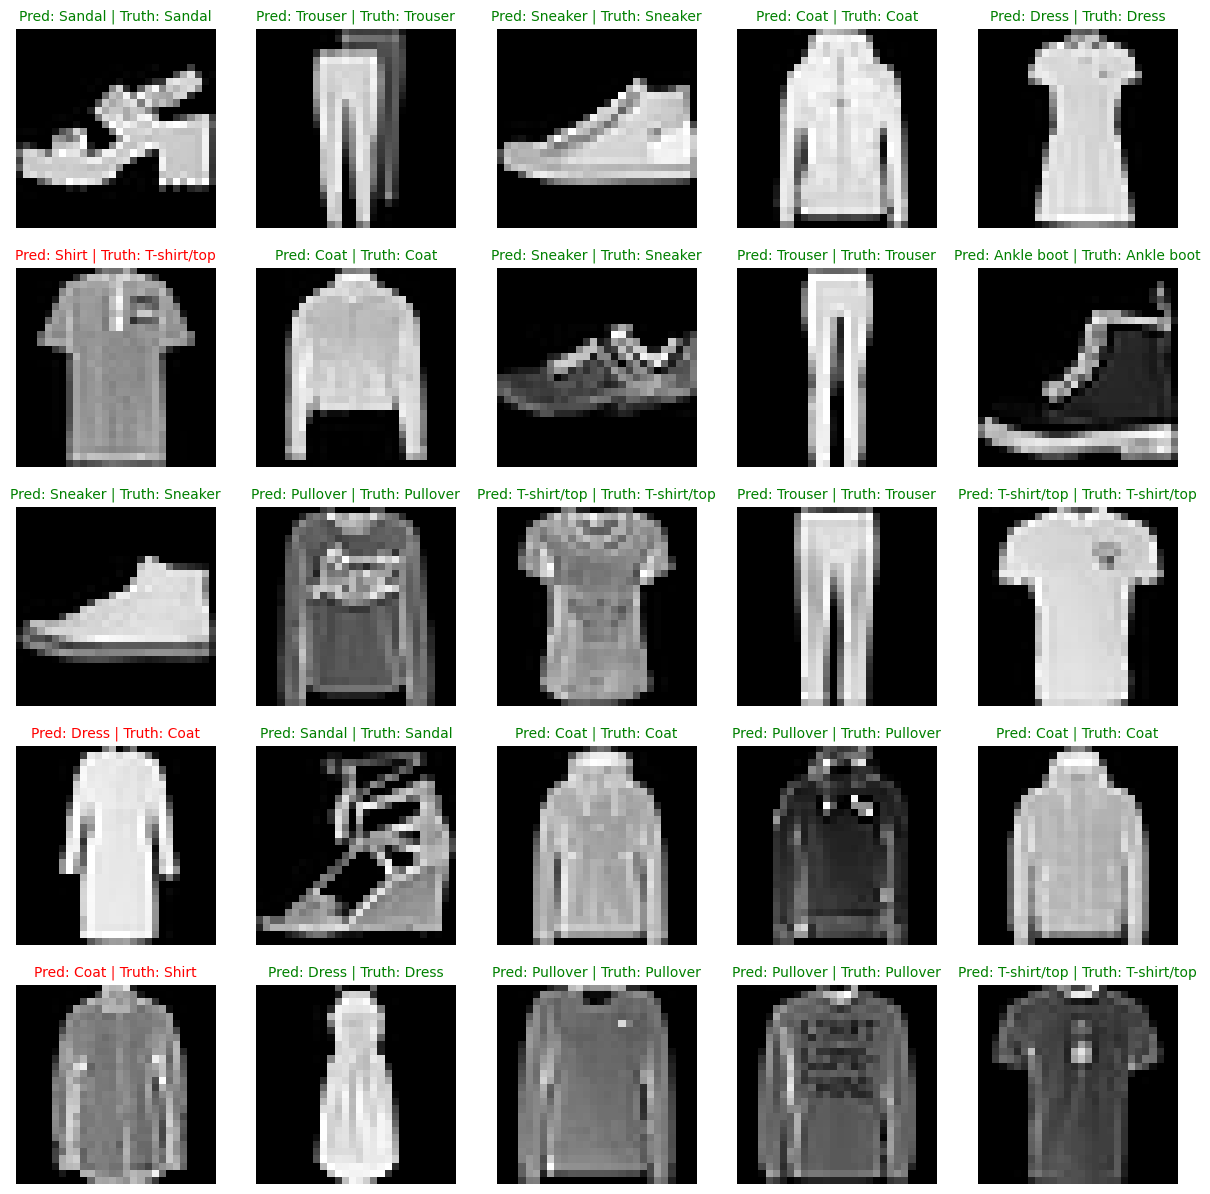

In [ ]:
# Plot predictions
plt.figure(figsize=(15,15))
nrows,ncols=5,5
for i,sample in enumerate(test_sample):
  #Create subplot
  plt.subplot(nrows,ncols,i+1)

  #plot target image
  plt.imshow(sample.squeeze(),cmap="gray")

  #Find the prediction label
  pred_label=class_names[pred_classes[i]]

  #Truth label
  truth_label=class_names[test_label[i]]

  # Create title text of the plot
  title_text=f"Pred: {pred_label} | Truth: {truth_label}"

  #Check for equality and change title color accordingly
  if pred_label==truth_label:
    plt.title(title_text,fontsize=10,c="g") # green text if correct
  else:
    plt.title(title_text,fontsize=10,c="r") #red text if wrong
  plt.axis(False)